# Full-Estonia crop segmentation: three models compared

Estonia 2021, every grid cell holding a declared parcel: **7,402 chips** of 224 x 224 pixels at 10 m,
twelve monthly Sentinel-2 composites. The partition is the spatial block split
`blocks4_buf1600_seed0`: blocks of 4 x 4 chips (8.96 km), whole blocks assigned to test, validation
and the training pool, and pool parcels within 1,600 m of a held-out block withheld from training.
Every model is scored on the **same 1,475 test chips** (127 blocks), labelled densely.

| Model | Features | Decoder input | Trained |
|---|---|---|---|
| TESSERA v1 + per-pixel MLP | precomputed annual embedding, 128-d per pixel | 10 m pixel raster | end to end on the embedding rasters |
| TerraMind v1 large | frozen encoder, twelve monthly passes | 14 x 14 token grid | two stages: cached features, then neck and UNet decoder |
| Prithvi-EO-2.0 600M TL | frozen encoder, one pass over twelve months | 16 x 16 token grid | two stages, as TerraMind |

Label budgets of 100, 20 and 5 % of the trainable parcels of each class, one draw and one seed per
cell, 15 epochs, and the checkpoint of lowest validation loss.

**Read the comparison with three caveats.** TESSERA and the two token-grid models sit in different
resolution groups, so a difference between them is not attributable to the encoder alone
(protocol D20, D21). Every cell is a single draw and seed, so there are no intervals yet. And the
checkpoint is chosen on validation loss, which for the token-grid models peaks several epochs
before validation Macro-F1 does (section 3).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

REPO = Path.cwd().resolve()
while not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))
from gfm4agri.benchmark.evaluation import FitPredictor, confusion, f1_from_iou, per_class_scores

ROOT = REPO / "data/eurocrops_chips/EE_2021"
SPLIT = ROOT / "splits/blocks4_buf1600_seed0__6b0eb4cb"
PRED_DIR = REPO / "results/seg_cached/ee_predictions"   # test predictions, cached after the first run
MODELS = {
    "TESSERA + MLP": REPO / "results/seg/tessera_v1_mlp_ee",
    "TerraMind v1 large": REPO / "results/seg_cached/terramind_v1_large_ee",
    "Prithvi-EO-2.0 600M TL": REPO / "results/seg_cached/prithvi_eo_v2_600_tl_ee",
}
BUDGETS = [100, 20, 5]
COLOURS = dict(zip(MODELS, ["#2a9d8f", "#e76f51", "#264653"]))


def fit_dir(model, pct):
    return MODELS[model] / f"P{pct}_draw0_seed0"


manifest = json.loads((ROOT / "manifest.json").read_text())
split = json.loads((SPLIT / "split.json").read_text())
chips = pd.read_csv(SPLIT / "chips.csv")
CLASSES = [c["name"] for c in manifest["classes"]]
SHORT = {
    "pasture_meadow_grassland_grass": "grassland", "winter_common_soft_wheat": "winter wheat",
    "legumes_harvested_green": "legumes, green", "spring_barley": "spring barley", "oats": "oats",
    "clover": "clover", "winter_rapeseed_rape": "winter rapeseed",
    "spring_common_soft_wheat": "spring wheat", "peas": "peas", "potatoes": "potatoes",
    "winter_barley": "winter barley", "beans": "beans", "fresh_vegetables": "vegetables",
    "rye": "rye", "alfalfa_lucerne": "alfalfa", "spring_rapeseed_rape": "spring rapeseed",
    "buckwheat": "buckwheat", "grain_maize_corn_popcorn": "maize",
    "legumes_dried_pulses_protein_crops": "dried pulses", "orchards_fruits": "orchards",
}
NAMES = [SHORT.get(c, c) for c in CLASSES]
print(f"{len(chips):,} chips; test {split['lists']['test']}, validation {split['lists']['validation']}, "
      f"training {split['lists']['training']}; {len(CLASSES)} classes")

7,402 chips; test 1475, validation 769, training 4898; 20 classes


## 1. The results

One row per fit. `parcels` is the support set the budget drew, `train chips` the chips holding at
least one of those parcels. `ckpt epoch` is the epoch whose weights were tested, the one of lowest
validation loss; `best val F1 epoch` is where validation Macro-F1 peaked.

In [2]:
rows = []
for model in MODELS:
    for pct in BUDGETS:
        d = fit_dir(model, pct)
        r = json.loads((d / "results.json").read_text())
        t = r["test_metrics"]
        log = pd.read_csv(d / "logs/version_0/metrics.csv").dropna(subset=["val/loss"])
        rows.append({
            "model": model, "budget %": pct,
            "parcels": sum(v["drawn"] for v in r["label_budget"]["support"].values()),
            "train chips": r["chips"]["train"],
            "Macro-F1": t["test/F1_Score"], "mIoU": t["test/mIoU"],
            "pixel accuracy": t["test/Pixel_Accuracy"],
            "trainable params (M)": r["params"]["trainable_total"] / 1e6,
            "fit (h)": r["fit_seconds"] / 3600,
            "ckpt epoch": int(log.loc[log["val/loss"].idxmin(), "epoch"]),
            "best val F1 epoch": int(log.loc[log["val/F1_Score"].idxmax(), "epoch"]),
        })
res = pd.DataFrame(rows)
res.style.format({"Macro-F1": "{:.3f}", "mIoU": "{:.3f}", "pixel accuracy": "{:.3f}",
                  "trainable params (M)": "{:.1f}", "fit (h)": "{:.2f}", "parcels": "{:,}"}) \
   .background_gradient(subset=["Macro-F1", "mIoU"], cmap="Greens").hide(axis="index")

model,budget %,parcels,train chips,Macro-F1,mIoU,pixel accuracy,trainable params (M),fit (h),ckpt epoch,best val F1 epoch
TESSERA + MLP,100,"86,909",4898,0.631,0.523,0.795,0.2,1.17,14,14
TESSERA + MLP,20,"17,390",4213,0.611,0.504,0.777,0.2,0.93,14,14
TESSERA + MLP,5,"4,354",2706,0.568,0.460,0.758,0.2,0.67,13,13
TerraMind v1 large,100,"86,909",4898,0.586,0.483,0.793,53.3,1.75,7,13
TerraMind v1 large,20,"17,390",4213,0.479,0.378,0.739,53.3,1.45,6,13
TerraMind v1 large,5,"4,354",2706,0.362,0.269,0.651,53.3,0.91,9,13
Prithvi-EO-2.0 600M TL,100,"86,909",4898,0.573,0.470,0.786,62.7,2.42,7,13
Prithvi-EO-2.0 600M TL,20,"17,390",4213,0.496,0.386,0.734,62.7,1.95,8,13
Prithvi-EO-2.0 600M TL,5,"4,354",2706,0.368,0.278,0.670,62.7,1.17,9,13


## 2. Learning curves

Test Macro-F1 and mIoU against the label budget. The x axis is the share of each class's
trainable parcels; the number of parcels drawn is written under each budget.

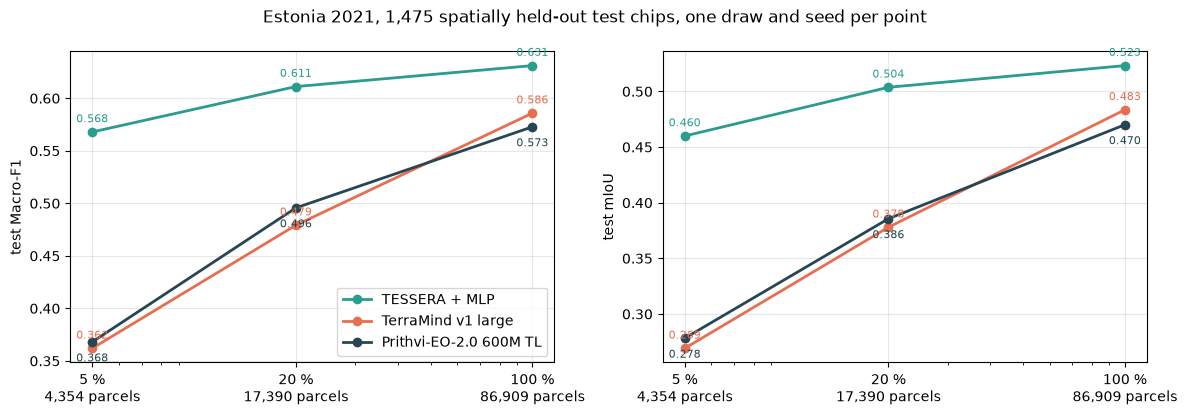

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, metric in zip(axes, ["Macro-F1", "mIoU"]):
    for model in MODELS:
        s = res[res["model"] == model].sort_values("budget %")
        ax.plot(s["budget %"], s[metric], "o-", color=COLOURS[model], label=model, lw=2)
        dy = -14 if model.startswith("Prithvi") else 7   # keep the two token-grid labels apart
        for x, y in zip(s["budget %"], s[metric]):
            ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, dy),
                        ha="center", fontsize=8, color=COLOURS[model])
    parcels = res.drop_duplicates("budget %").set_index("budget %")["parcels"]
    ax.set_xscale("log")
    ax.set_xticks(BUDGETS)
    ax.set_xticklabels([f"{p} %\n{parcels[p]:,} parcels" for p in BUDGETS])
    ax.set_ylabel(f"test {metric}")
    ax.grid(alpha=0.3)
axes[0].legend(loc="lower right")
fig.suptitle("Estonia 2021, 1,475 spatially held-out test chips, one draw and seed per point")
fig.tight_layout()

## 3. Validation curves at 100 %

Validation Macro-F1 and loss per epoch. The dot marks the epoch whose checkpoint was tested. For the
two token-grid models the loss turns upward after about epoch 7 while Macro-F1 keeps rising, so a
checkpoint chosen on Macro-F1 would have scored higher; TESSERA is still improving on both at the
last epoch, so it is undertrained rather than overfitted.

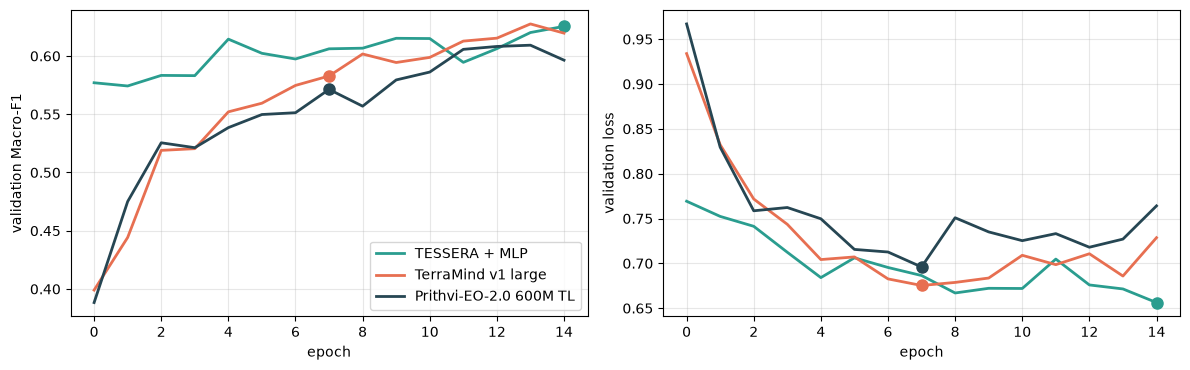

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for model in MODELS:
    log = pd.read_csv(fit_dir(model, 100) / "logs/version_0/metrics.csv").dropna(subset=["val/loss"])
    best = log.loc[log["val/loss"].idxmin()]
    for ax, key in zip(axes, ["val/F1_Score", "val/loss"]):
        ax.plot(log["epoch"], log[key], "-", color=COLOURS[model], label=model, lw=2)
        ax.plot(best["epoch"], best[key], "o", color=COLOURS[model], ms=8)
axes[0].set_ylabel("validation Macro-F1")
axes[1].set_ylabel("validation loss")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
axes[0].legend()
fig.tight_layout()

## 4. Per-class F1

Per-class F1 from the per-class IoU each fit recorded on the test set, F1 = 2 IoU / (1 + IoU),
which holds exactly class by class. Classes are ordered by the number of test parcels, given in
brackets; the protocol asks for at least 200 for a per-class score to be meaningful.

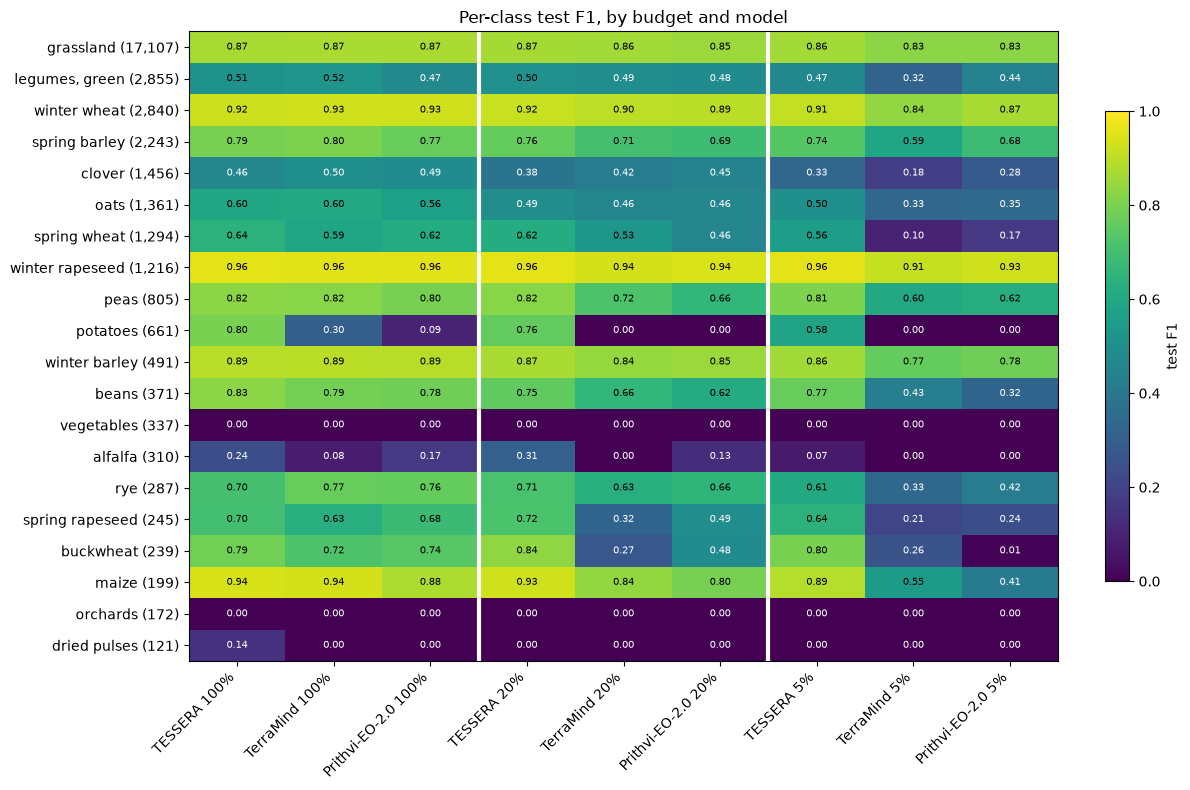

In [5]:
test_parcels = {c: split["per_class_parcels"][c]["test"] for c in CLASSES}
order = sorted(CLASSES, key=lambda c: -test_parcels[c])
cols, mat = [], []
for pct in BUDGETS:
    for model in MODELS:
        t = json.loads((fit_dir(model, pct) / "results.json").read_text())["test_metrics"]
        mat.append([f1_from_iou(t.get(f"test/IoU_{c}", np.nan)) for c in order])
        cols.append(f"{model.split(' ')[0]} {pct}%")
mat = np.array(mat).T

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(mat, cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right")
ax.set_yticks(range(len(order)), [f"{SHORT.get(c, c)} ({test_parcels[c]:,})" for c in order])
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        if np.isfinite(mat[i, j]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if mat[i, j] < 0.5 else "black")
for x in (2.5, 5.5):
    ax.axvline(x, color="white", lw=3)
fig.colorbar(im, ax=ax, label="test F1", fraction=0.025)
ax.set_title("Per-class test F1, by budget and model")
fig.tight_layout()

## 5. Predicting the test chips

The 100 % fits are reloaded from their checkpoints and run over all 1,475 test chips. The first run
takes about twenty minutes, most of it reading the cached features and the TESSERA rasters from the
network drive; the predictions are then stored under `results/seg_cached/ee_predictions/` and later
runs read them back. The Macro-F1 recomputed from these predictions is checked against the one
TerraTorch logged during the test, as a guard that the reloaded models are the trained ones.

In [6]:
test_ids = (SPLIT / "test_data.txt").read_text().split()


def test_predictions(model, pct=100):
    path = PRED_DIR / f"{MODELS[model].name}_P{pct}.npz"
    if not path.exists():
        p = FitPredictor(fit_dir(model, pct))
        out = p.predict(test_ids, num_workers=16)
        ids = sorted(out)
        PRED_DIR.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(path, ids=np.array(ids), pred=np.stack([out[i][0] for i in ids]),
                            mask=np.stack([out[i][1] for i in ids]))
        del p
        torch.cuda.empty_cache()
    z = np.load(path)
    return {i: (p, m) for i, p, m in zip(z["ids"], z["pred"], z["mask"])}


PRED = {model: test_predictions(model) for model in MODELS}
CM = {m: sum(confusion(p, k, len(CLASSES)) for p, k in PRED[m].values()) for m in MODELS}
check = []
for m in MODELS:
    s = per_class_scores(CM[m])
    logged = res[(res["model"] == m) & (res["budget %"] == 100)].iloc[0]
    check.append({"model": m, "Macro-F1 recomputed": s["macro_f1"], "Macro-F1 logged": logged["Macro-F1"],
                  "mIoU recomputed": s["miou"], "mIoU logged": logged["mIoU"],
                  "pixel accuracy": s["accuracy"]})
pd.DataFrame(check).style.format(precision=4).hide(axis="index")

model,Macro-F1 recomputed,Macro-F1 logged,mIoU recomputed,mIoU logged,pixel accuracy
TESSERA + MLP,0.6311,0.6311,0.5232,0.5232,0.7946
TerraMind v1 large,0.5858,0.5858,0.4835,0.4835,0.7928
Prithvi-EO-2.0 600M TL,0.5728,0.5728,0.4701,0.4701,0.7861


### Confusion at 100 %

Row-normalised confusion over all labelled test pixels: each row is a reference class and shows
where its pixels went. Off-diagonal blocks show which crops the models mistake for each other.

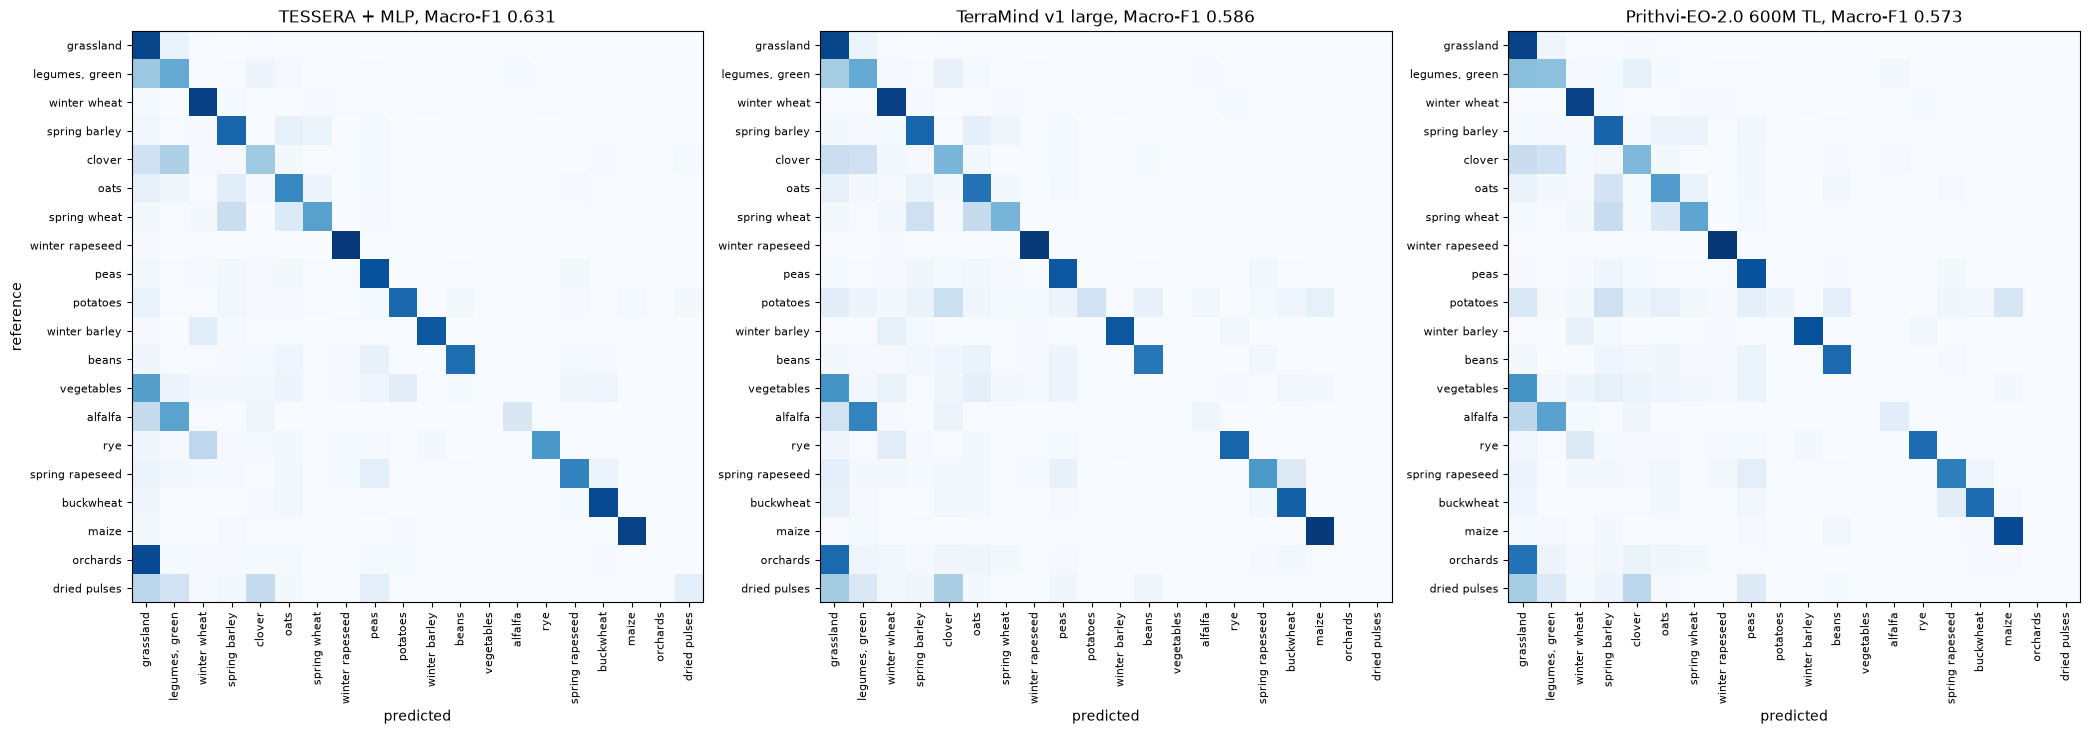

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, m in zip(axes, MODELS):
    cm = CM[m][np.ix_([CLASSES.index(c) for c in order], [CLASSES.index(c) for c in order])]
    norm = cm / np.maximum(cm.sum(1, keepdims=True), 1)
    ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(order)), [SHORT.get(c, c) for c in order], rotation=90, fontsize=8)
    ax.set_yticks(range(len(order)), [SHORT.get(c, c) for c in order], fontsize=8)
    ax.set_xlabel("predicted")
    ax.set_title(f"{m}, Macro-F1 {per_class_scores(CM[m])['macro_f1']:.3f}")
axes[0].set_ylabel("reference")
fig.tight_layout()

### Where the models fail

Pixel accuracy of each test chip over its labelled pixels, placed on the chip grid. Grey chips are
the training and validation chips.

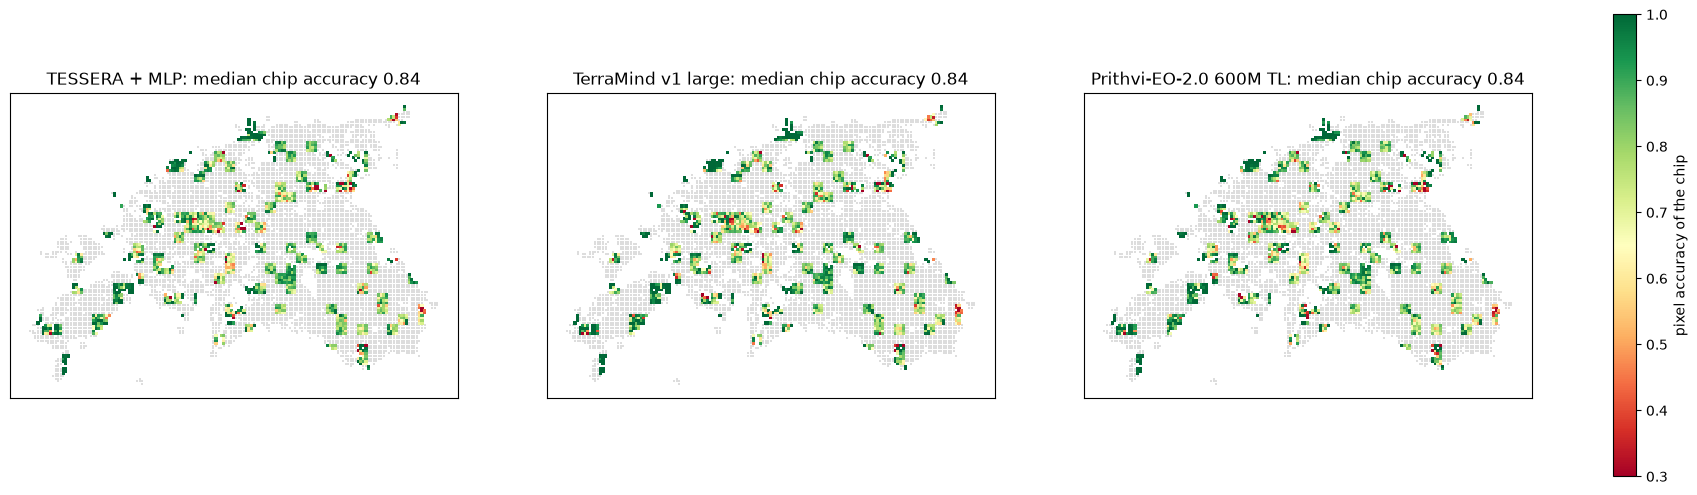

In [8]:
grid = chips.set_index("chip_id")
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
for ax, m in zip(axes, MODELS):
    acc = {c: float((p[k >= 0] == k[k >= 0]).mean()) for c, (p, k) in PRED[m].items() if (k >= 0).any()}
    other = grid[grid["partition"] != "test"]
    ax.scatter(other["col"], other["row"], s=3, marker="s", c="#dddddd", linewidths=0)
    t = grid.loc[list(acc)]
    sc = ax.scatter(t["col"], t["row"], s=5, marker="s", c=list(acc.values()), cmap="RdYlGn",
                    vmin=0.3, vmax=1, linewidths=0)
    ax.set_aspect("equal")
    ax.set_title(f"{m}: median chip accuracy {np.median(list(acc.values())):.2f}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(sc, ax=axes, label="pixel accuracy of the chip", fraction=0.015)

## 6. Segmented test chips

Six test chips with many crops and a high labelled share, from six different blocks. Each row shows
a July true-colour composite, the reference labels, and the three models' predictions at 100 %.
Predictions are shown on the declared parcels only: outside them the crop-type model has no
target, since the cropland stage of the two-stage segmentation is not built yet.

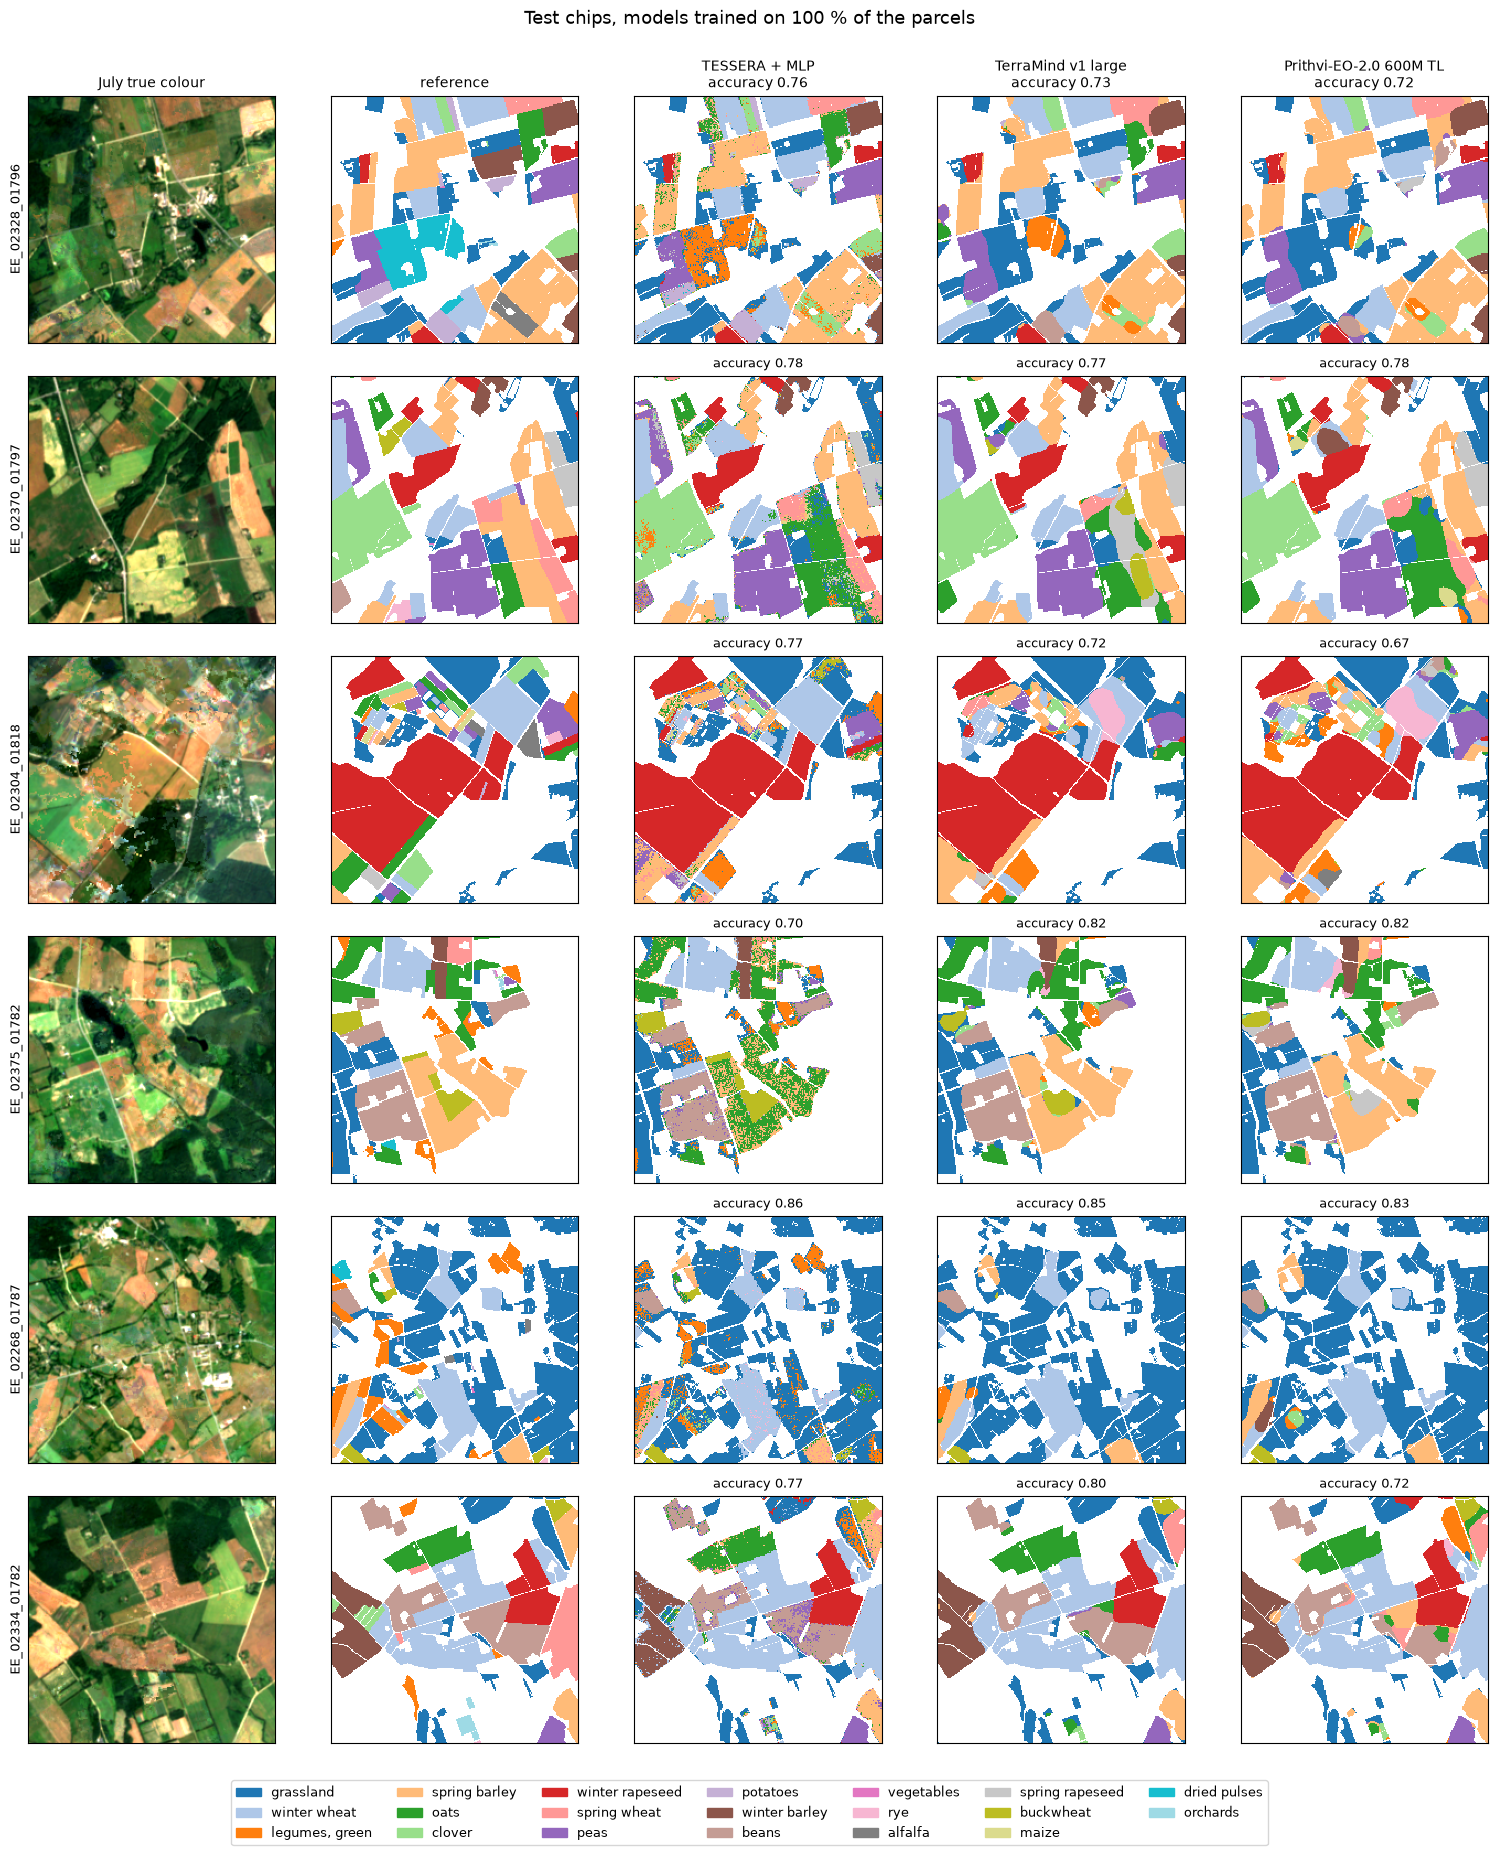

In [9]:
test_meta = {c["chip_id"]: c for c in manifest["chips"] if c["chip_id"] in set(test_ids)}
cand = sorted(test_meta.values(),
              key=lambda c: (-len(c["pixels_per_class"]), -c["labelled_share"]))
SHOW, blocks = [], set()
for c in cand:
    b = grid.loc[c["chip_id"], "block_id"]
    if c["labelled_share"] >= 0.35 and b not in blocks:
        SHOW.append(c["chip_id"])
        blocks.add(b)
    if len(SHOW) == 6:
        break

CMAP = ListedColormap(plt.get_cmap("tab20").colors[: len(CLASSES)])
BANDS = manifest["imagery"]["band_names"]


def true_colour(cid, month=6):
    with rasterio.open(ROOT / "chips" / f"{cid}_merged.tif") as src:
        a = src.read([month * len(BANDS) + BANDS.index(b) + 1 for b in ("RED", "GREEN", "BLUE")])
    a = np.moveaxis(a.astype(float) / 10000, 0, -1)
    lo, hi = np.percentile(a, [2, 98])
    return np.clip((a - lo) / (hi - lo), 0, 1)


def show_chips(pred_by_model, title):
    cols = ["July true colour", "reference"] + list(MODELS)
    fig, axes = plt.subplots(len(SHOW), len(cols), figsize=(3.1 * len(cols), 3.1 * len(SHOW)))
    present = set()
    for i, cid in enumerate(SHOW):
        mask = PRED[next(iter(MODELS))][cid][1]
        lab = mask >= 0
        present |= set(np.unique(mask[lab]).tolist())
        axes[i, 0].imshow(true_colour(cid))
        axes[i, 1].imshow(np.ma.masked_where(~lab, mask), cmap=CMAP, vmin=-0.5, vmax=len(CLASSES) - 0.5,
                          interpolation="nearest")
        axes[i, 0].set_ylabel(cid, fontsize=9)
        for j, m in enumerate(MODELS, start=2):
            p = pred_by_model[m][cid]
            acc = (p[lab] == mask[lab]).mean()
            axes[i, j].imshow(np.ma.masked_where(~lab, p), cmap=CMAP, vmin=-0.5,
                              vmax=len(CLASSES) - 0.5, interpolation="nearest")
            axes[i, j].set_title(f"accuracy {acc:.2f}", fontsize=9)
        for j, name in enumerate(cols):
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
            if i == 0:
                axes[i, j].set_title(name + ("\n" + axes[i, j].get_title() if j >= 2 else ""), fontsize=10)
    handles = [Patch(color=CMAP(k), label=NAMES[k]) for k in sorted(present)]
    fig.legend(handles=handles, loc="lower center", ncol=min(7, len(handles)), fontsize=9,
               bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=(0, 0.04, 1, 0.98))


show_chips({m: {c: PRED[m][c][0] for c in SHOW} for m in MODELS},
           "Test chips, models trained on 100 % of the parcels")

### The same chips at 5 %

The same six chips predicted by the fits trained on 5 % of the parcels, about 4,400 polygons for
the whole country, to show what the label budget costs on the map.

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


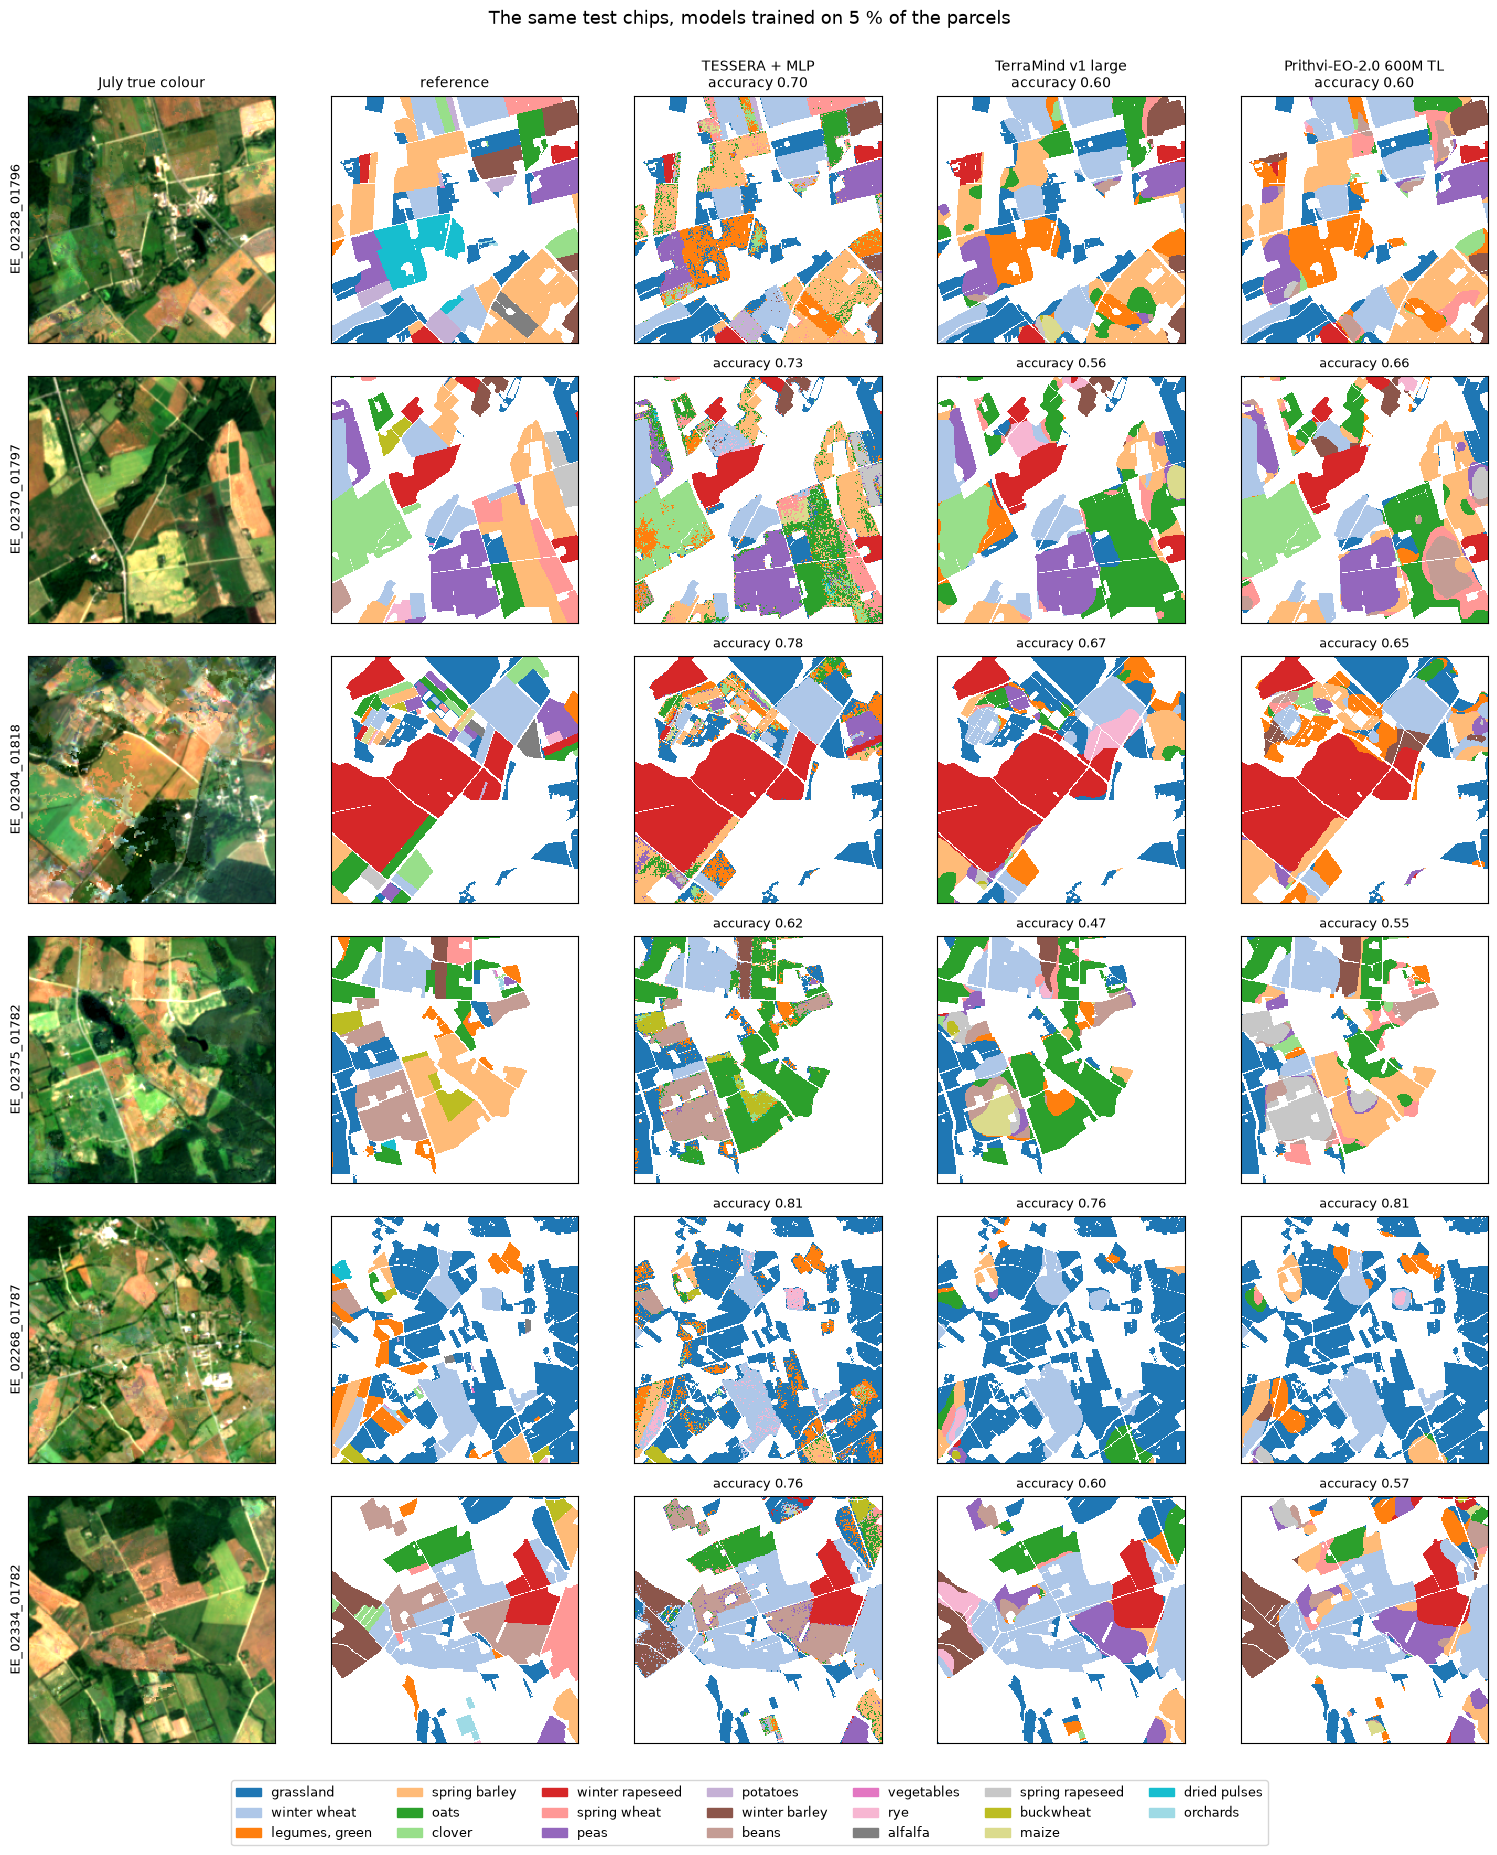

In [10]:
low = {}
for m in MODELS:
    p = FitPredictor(fit_dir(m, 5))
    low[m] = {c: v[0] for c, v in p.predict(SHOW, num_workers=4).items()}
    del p
    torch.cuda.empty_cache()
show_chips(low, "The same test chips, models trained on 5 % of the parcels")

## 7. Reading the results

* **TESSERA keeps its level as labels become scarce.** It loses about 0.06 Macro-F1 from 100 % to
  5 %, against about 0.21 for both token-grid models. Part of this gap is the decoder input: a
  per-pixel head on 10 m embeddings keeps parcel boundaries that a 14 x 14 or 16 x 16 token grid
  has to recover by upsampling. The resolution bridge of protocol D22 is what separates the two.
* **The maps show the two decoder inputs at work.** TESSERA's predictions follow parcel edges but
  are speckled pixel by pixel, since its head sees each pixel alone; the token-grid models give
  clean, smooth parcels whose edges bleed across field boundaries, and at 5 % they degrade into
  rounded blobs that ignore the parcels altogether. All three reach the same median chip
  accuracy, 0.84, so the Macro-F1 gap sits in the classes rather than in the typical chip.
* **The hard classes are the same for every model.** Green legumes, clover and alfalfa go to
  grassland, spring wheat to spring barley and oats, and vegetables and orchards, small and few,
  are almost never predicted at all. These are the classes the 200 test parcel threshold and the
  class scheme decisions have to address.
* **TerraMind large and Prithvi 600M TL are indistinguishable here.** They differ by at most 0.02
  at every budget, inside what a second seed would move.
* **Not yet an answer to RQ1.** The raw-feature baseline that the label budget is measured against
  has not been run, and each point is a single draw and seed.
* **Open choices that move these numbers:** the checkpoint criterion (section 3), the block size,
  and the 0.66 % of test pixels without a TESSERA embedding, which TESSERA currently sees as zeros.